--- 1. Dataset Shape ---
Number of rows: 9551
Number of columns: 21

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   ob

/tmp/ipykernel_1156/2154463468.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


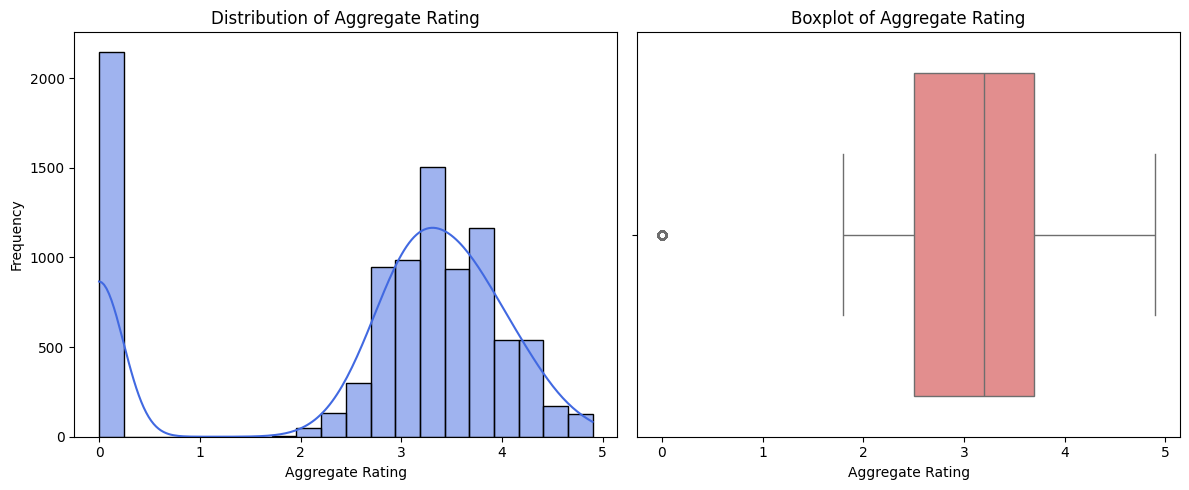

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset (update filename/path as needed)
df = pd.read_csv(r'/content/sample_data/Dataset .csv')

# 1. Dataset Dimensions
print("--- 1. Dataset Shape ---")
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")
print("\nDataset Info:")
print(df.info())

# 2. Missing Value Analysis & Handling
print("\n--- 2. Missing Values ---")
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# Strategy: Impute or Drop
# For numerical columns (median/mean)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical/text columns (mode or 'Unknown')
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Data Type Conversion
print("\n--- 3. Data Type Conversion ---")
# Ensure target variable is float
df["Aggregate rating"] = pd.to_numeric(
    df["Aggregate rating"], errors="coerce"
)

# Convert categorical features to category dtype if needed
for col in cat_cols:
  df[col] = df[col].astype("category")

print("Updated Data Types:")
print(df.dtypes)

# 4. Target Variable Analysis & Class Imbalance
print("\n--- 4. Target Variable Distribution ---")
rating_stats = df["Aggregate rating"].describe()
print(rating_stats)

# Value counts to identify zero-rating or specific rating spikes
value_counts = df["Aggregate rating"].value_counts().sort_index()
print("\nRating Frequency Distribution:")
print(value_counts)

# Visualizations
plt.figure(figsize=(12, 5))

# Subplot 1: Distribution Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df["Aggregate rating"], bins=20, kde=True, color="royalblue")
plt.title("Distribution of Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")

# Subplot 2: Boxplot to spot outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df["Aggregate rating"], color="lightcoral")
plt.title("Boxplot of Aggregate Rating")
plt.xlabel("Aggregate Rating")

plt.tight_layout()
plt.show()

# New Section